In [1]:
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import *
import chardet
import datetime

In [2]:
data_players = pd.read_csv('data_players.csv')
data_match_scores = pd.read_csv('match_scores.csv')
data_match_stats = pd.read_csv('match_stats.csv')
data_rankings_1 = pd.read_csv('rankings.csv')
data_rankings_2=pd.read_csv('rankings_2.csv')
data_rankings_3=pd.read_csv('rankings_3.csv')
data_rankings=pd.concat([data_rankings_1,data_rankings_2,data_rankings_3])
annee_debut=1960
diametre_balle=6.5
players_non_retraites=data_players.birth_year>=annee_debut
players_taille_ok=data_players.height_cm>diametre_balle
data_players_choisis=data_players[players_non_retraites & players_taille_ok]

In [3]:
###HISTOGRAMME TAILLES
annee_debut=1960
nb_joueurs = data_players_choisis['player_id'].count()
moy= data_players_choisis['height_cm'].mean()
media= data_players_choisis['height_cm'].median()
ecart= data_players_choisis['height_cm'].std()
#data_tri2 = data_players_choisis.groupby("player_id").agg({"height_cm":["mean","median"]})
print("nombre de jours ", nb_joueurs)
print("moyenne", moy)
print("median ", media)
print("_________________serie_______________")
serie1 = pd.Series([nb_joueurs,moy,media,ecart], index= ['nb_joueurs','taille_moy','taille_media','́ecart type'])
print(serie1)


nombre de jours  2220
moyenne 184.16981981981982
median  183.0
_________________serie_______________
nb_joueurs      2220.000000
taille_moy       184.169820
taille_media     183.000000
́ecart type        6.540303
dtype: float64


2        188.0
4        180.0
5        183.0
10       180.0
13       191.0
         ...  
10877    198.0
10878    180.0
10881    193.0
10886    180.0
10898    185.0
Name: height_cm, Length: 2220, dtype: float64
[160. 165. 170. 175. 180. 185. 190. 195. 200. 205. 210. 215.]


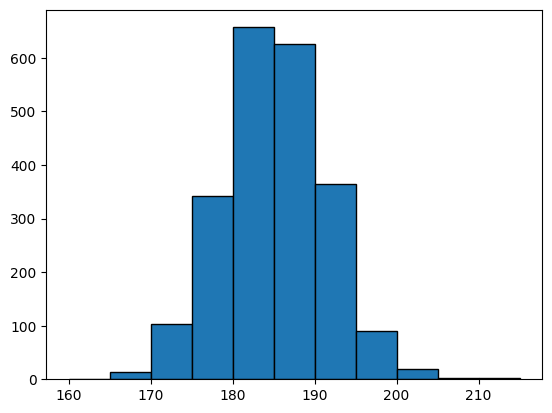

In [4]:
taille = data_players_choisis['height_cm']
xmin_gr = np.floor(taille.min()/5)*5
xmax_gr = np.floor(taille.max()/5)*5 + 5 *2
liste_borne = np.arange(xmin_gr,xmax_gr,5)

plt.hist(taille,bins=liste_borne,edgecolor='black')
print(taille)
print(liste_borne)


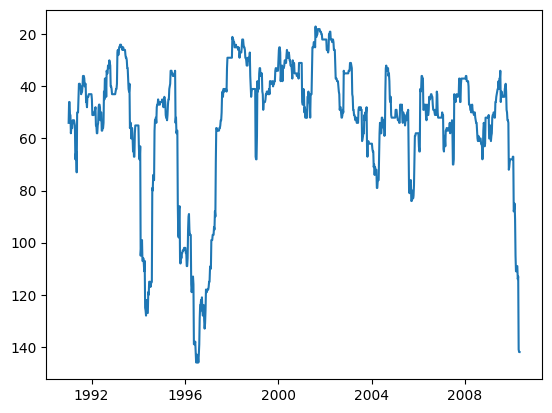

In [10]:
###Graphique évolution classement
joueur_voulu='s424'
joueur = data_rankings[data_rankings['player_id']==joueur_voulu]
data = joueur.sort_values(by='week_title')
data_1 = data["week_title"].str.replace(".","-")
date = pd.to_datetime(data_1)
plt.plot(date,data["rank_number"])
plt.gca().invert_yaxis()
#Pour avoir son vecteur de données en abscisses après avoir trié selon week_title pour obtenir dates:
#x_graph=np.char.replace(dates.values.astype('str'),'.','-').astype('datetime64')

In [6]:
###CORRELATION TAILLE/ TAUX POINTS GAGNES APRES PREMIERS SERVICES REUSSIS


#A la fin pour ne pas exclure de la représentation les joueurs qui n'auraient rien gagné par exemple :
#stats_matchs_par_joueur=stats_matchs_par_joueur.fillna(0)